In [1]:
import os
os.chdir('../../..')

In [21]:
import chemiscope
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from src.non_euclidean import _compute_invariant_feature_matrix as invariant_matrix
from src.datasets import QM9Dataset

In [3]:
qm9 = QM9Dataset()
qm9.load()
frames = qm9.get_positions()

2026-03-24 09:10:12.348 | INFO     | src.datasets:load:383 - Loading QM9 from data/QM9/dataset_cleaned.parquet...


2026-03-24 09:10:23.040 | SUCCESS  | src.datasets:get_positions:949 - Saved 2000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 2000).


In [14]:
frames[0]

Atoms(symbols='HOH', pbc=False, initial_charges=..., mass=..., partial_charge=...)

In [23]:
matrices = [invariant_matrix(frame) for frame in frames]

max_atoms = max(matrix.shape[1] for matrix in matrices)
num_properties = matrices[0].shape[0]

flattened_padded_matrices = []

for matrix in matrices:
    current_atoms = matrix.shape[1]
    
    padded_matrix = np.zeros((num_properties, max_atoms))
    
    padded_matrix[:, :current_atoms] = matrix
    
    vector = padded_matrix.flatten()
    flattened_padded_matrices.append(vector)

X = np.array(flattened_padded_matrices)

Evaluating cluster numbers. This may take a moment...


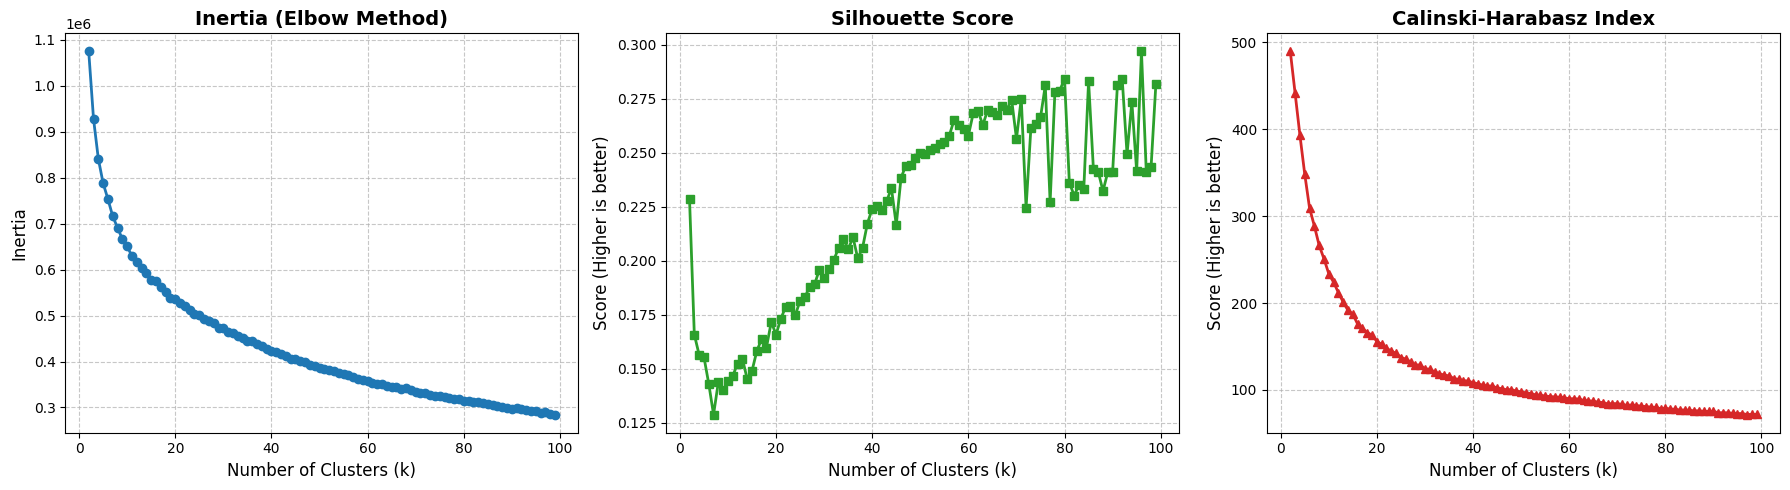

Optimal clusters based on Silhouette Score: 96
Optimal clusters based on Calinski-Harabasz: 2

Refitting KMeans with optimal k=96...


In [30]:
k_range = range(2, 100)

inertias = []
silhouette_scores = []
ch_scores = []

print("Evaluating cluster numbers. This may take a moment...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(k_range, inertias, marker='o', linestyle='-', color='tab:blue', linewidth=2)
axs[0].set_title('Inertia (Elbow Method)', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axs[0].set_ylabel('Inertia', fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.7)

axs[1].plot(k_range, silhouette_scores, marker='s', linestyle='-', color='tab:green', linewidth=2)
axs[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axs[1].set_ylabel('Score (Higher is better)', fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.7)

axs[2].plot(k_range, ch_scores, marker='^', linestyle='-', color='tab:red', linewidth=2)
axs[2].set_title('Calinski-Harabasz Index', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axs[2].set_ylabel('Score (Higher is better)', fontsize=12)
axs[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_k_ch = k_range[np.argmax(ch_scores)]

print(f"Optimal clusters based on Silhouette Score: {best_k_silhouette}")
print(f"Optimal clusters based on Calinski-Harabasz: {best_k_ch}")

best_k = best_k_silhouette
print(f"\nRefitting KMeans with optimal k={best_k}...")

best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = best_kmeans.fit_predict(X)

In [31]:
num_clusters = 70
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X)

Running t-SNE on 2000 samples...


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_83215/2653687064.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


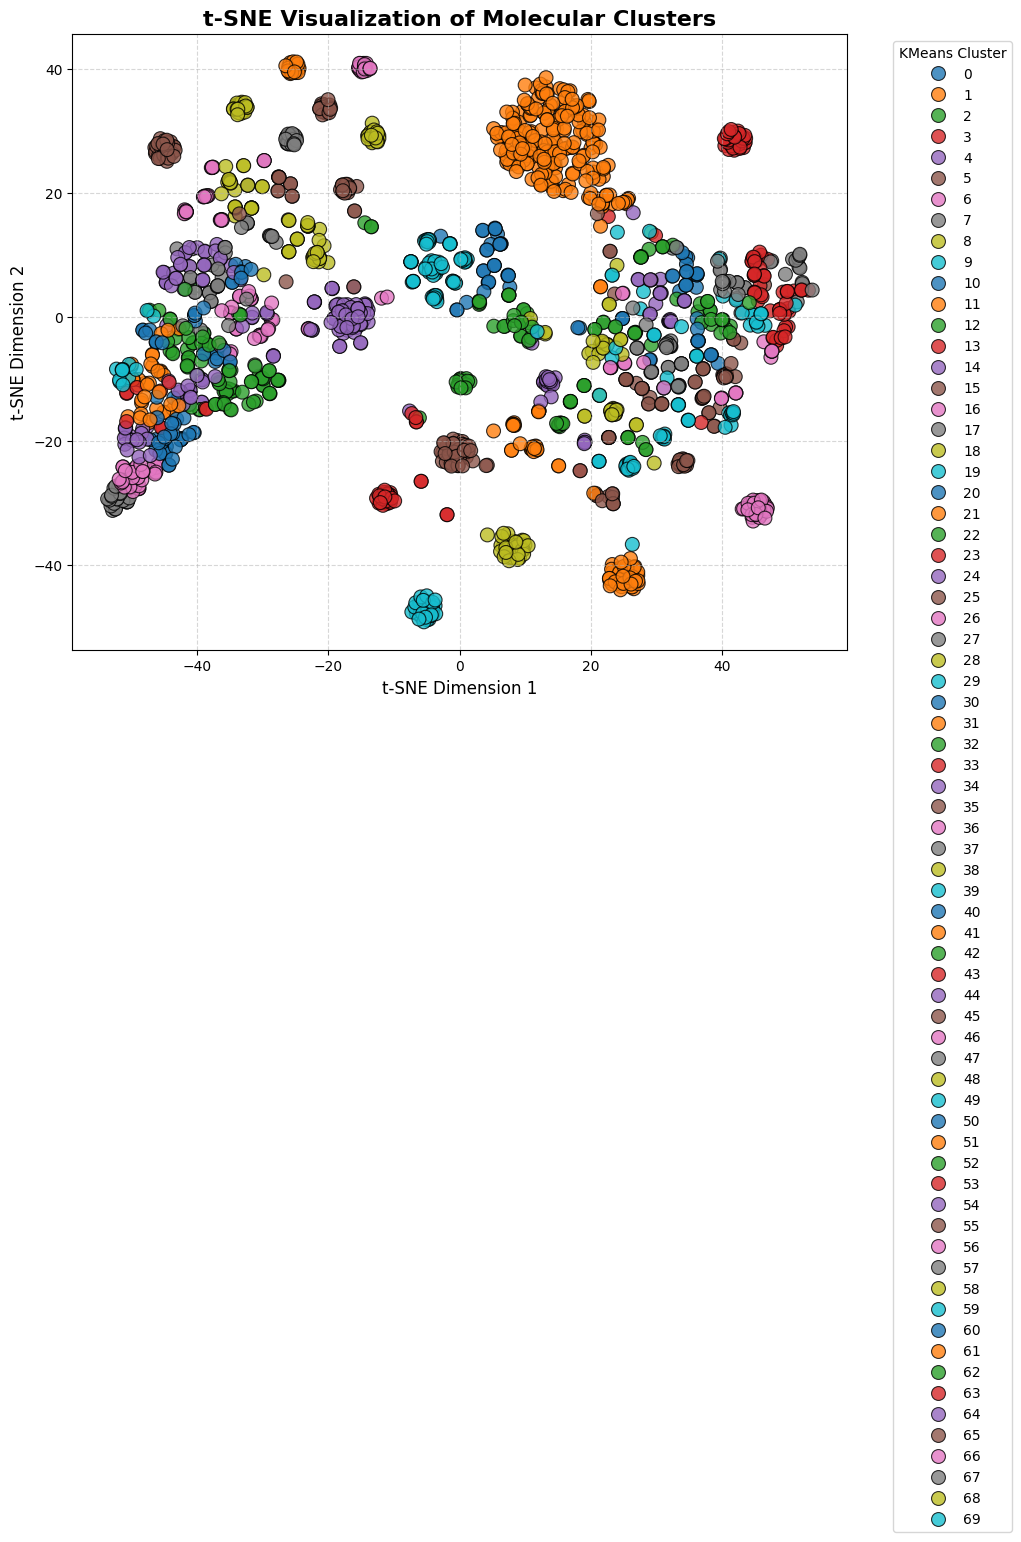

In [32]:
n_samples = X.shape[0]
perplexity_value = min(30, n_samples - 1)

print(f"Running t-SNE on {n_samples} samples...")

tsne = TSNE(
    n_components=2, 
    random_state=42, 
    perplexity=perplexity_value,
    init='pca',
    learning_rate='auto'
)

X_tsne = tsne.fit_transform(X)

# 2. Create the plot
plt.figure(figsize=(10, 8))

# Using Seaborn to create a scatter plot, colored by the KMeans cluster labels
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=cluster_labels, 
    palette="tab10",  # distinct colors for different clusters
    s=100,            # marker size
    alpha=0.8,        # slight transparency
    edgecolor="k"     # black borders around dots
)

plt.title("t-SNE Visualization of Molecular Clusters", fontsize=16, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)

plt.legend(title="KMeans Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [33]:
properties = {
    "UMAP 1": X_tsne[:, 0],
    "UMAP 2": X_tsne[:, 1],
    "Cluster": cluster_labels,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups":  qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Branching index": qm9.df["branching_index"].to_list(),
    "Main chain length": qm9.df["main_chain_length"].to_list(),
    "mu": qm9.df["mu"].to_list(),
    "Homo" : qm9.df["homo"].to_list(),
    "Lumo":qm9.df["lumo"].to_list(),
    "gap": qm9.df["gap"].to_list(),
    "r2":qm9.df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 3, 'data': 'structure-0'}, {'size': 4, 'data': 'str…